# Import library

In [51]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, InputLayer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Memuat Dataset

In [38]:
df = sns.load_dataset('penguins')

print("Dataset 'penguins' berhasil dimuat.")
print(f"Tipe data: {type(df)}")

Dataset 'penguins' berhasil dimuat.
Tipe data: <class 'pandas.core.frame.DataFrame'>


Dataset "penguins" dimuat langsung dari library Seaborn. Data ini disimpan ke dalam sebuah variabel DataFrame Pandas yang diberi nama `df` untuk pemrosesan lebih lanjut.

# 5 Data teratas

In [39]:
print("--- 5 Baris Pertama Data Mentah ---")
print(df.head())
print("-----------------------------------")

--- 5 Baris Pertama Data Mentah ---
  species     island  bill_length_mm  bill_depth_mm  flipper_length_mm  \
0  Adelie  Torgersen            39.1           18.7              181.0   
1  Adelie  Torgersen            39.5           17.4              186.0   
2  Adelie  Torgersen            40.3           18.0              195.0   
3  Adelie  Torgersen             NaN            NaN                NaN   
4  Adelie  Torgersen            36.7           19.3              193.0   

   body_mass_g     sex  
0       3750.0    Male  
1       3800.0  Female  
2       3250.0  Female  
3          NaN     NaN  
4       3450.0  Female  
-----------------------------------


Lima baris pertama dari DataFrame (`df.head()`) ditampilkan. Langkah ini bertujuan untuk mendapatkan pemahaman awal mengenai struktur data, nama-nama kolom, dan contoh isi dari setiap fitur.

# Data Info

In [40]:
print("--- Info Dataset (Tipe & Data Kosong) ---")
df.info()
print("------------------------------------------")

--- Info Dataset (Tipe & Data Kosong) ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    object 
 1   island             344 non-null    object 
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    object 
dtypes: float64(4), object(3)
memory usage: 18.9+ KB
------------------------------------------


Metode `.info()` digunakan untuk menampilkan ringkasan teknis DataFrame. Ini mencakup tipe data setiap kolom dan jumlah nilai non-null (tidak kosong), yang penting untuk mengidentifikasi data yang hilang.

# Membersihkan Data

In [41]:
# Bersihkan Data (buang baris yang datanya kosong/NaN)
jumlah_baris_sebelum = len(df)
df.dropna(inplace=True)
jumlah_baris_sesudah = len(df)

print("Data kosong (NaN) telah dibuang.")
print(f"Jumlah baris sebelumnya: {jumlah_baris_sebelum}")
print(f"Jumlah baris sekarang: {jumlah_baris_sesudah}")

Data kosong (NaN) telah dibuang.
Jumlah baris sebelumnya: 344
Jumlah baris sekarang: 333


Model *deep learning* tidak dapat memproses nilai yang hilang (NaN). Oleh karena itu, semua baris yang mengandung setidaknya satu nilai kosong akan dibuang dari DataFrame menggunakan `.dropna()`.

# Memisahkan Fitur (X) dan Target (y)

In [42]:
features = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']

X = df[features]
y = df['species'] # Target = 'species'

# Output:
print(" Data berhasil dipisah menjadi X (fitur) dan y (target).")
print("\n--- 5 Baris Pertama X (Fitur) ---")
print(X.head())
print("\n--- 5 Baris Pertama y (Target) ---")
print(y.head())

 Data berhasil dipisah menjadi X (fitur) dan y (target).

--- 5 Baris Pertama X (Fitur) ---
   bill_length_mm  bill_depth_mm  flipper_length_mm  body_mass_g
0            39.1           18.7              181.0       3750.0
1            39.5           17.4              186.0       3800.0
2            40.3           18.0              195.0       3250.0
4            36.7           19.3              193.0       3450.0
5            39.3           20.6              190.0       3650.0

--- 5 Baris Pertama y (Target) ---
0    Adelie
1    Adelie
2    Adelie
4    Adelie
5    Adelie
Name: species, dtype: object


Data dipisahkan menjadi dua komponen utama:
* **X (Fitur):** Variabel independen (input) yang akan digunakan model untuk melakukan prediksi.
* **y (Target):** Variabel dependen (output) yang ingin diprediksi oleh model (dalam kasus ini, kolom 'species').

Encoding Data

In [43]:
# Ubah 'y' (target) dari Teks menjadi Angka
encoder = LabelEncoder()
y_encoded = encoder.fit_transform(y)
num_classes = len(np.unique(y_encoded))

print(" Target (y) berhasil diubah dari Teks menjadi Angka.")
print(f"Target asli (unik): {y.unique()}")
print(f"Target setelah di-encode: {np.unique(y_encoded)}")
print(f"Jumlah kelas (spesies): {num_classes}")

 Target (y) berhasil diubah dari Teks menjadi Angka.
Target asli (unik): ['Adelie' 'Chinstrap' 'Gentoo']
Target setelah di-encode: [0 1 2]
Jumlah kelas (spesies): 3


Model memerlukan input numerik. `LabelEncoder` dari Sklearn diterapkan pada variabel target (y) untuk mengubah nilai teks (spesies pinguin) menjadi representasi angka (misalnya: 0, 1, 2).

# Normalisasi Fitur (Standard Scaling)

In [44]:
# Normalisasi/Scaling Fitur (X)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Output:
print(" Fitur (X) berhasil di-scaling.")
print("\n--- Baris pertama X (sebelum scaling) ---")
print(X.iloc[0].values)
print("\n--- Baris pertama X (setelah scaling) ---")
print(X_scaled[0])

 Fitur (X) berhasil di-scaling.

--- Baris pertama X (sebelum scaling) ---
[  39.1   18.7  181.  3750. ]

--- Baris pertama X (setelah scaling) ---
[-0.89604189  0.7807321  -1.42675157 -0.56847478]


`StandardScaler` diterapkan pada himpunan fitur (X) untuk menormalkan skala nilainya. Ini adalah langkah *preprocessing* penting yang membantu proses *training* model *deep learning* agar lebih cepat dan stabil.

# Split Data

In [45]:
# Split Data (80% training, 20% validation)
X_train, X_val, y_train, y_val = train_test_split(
    X_scaled, y_encoded, test_size=0.2, random_state=42
)

print(" Data berhasil dibagi menjadi data training dan validation.")
print(f"Jumlah data training: {X_train.shape[0]} baris")
print(f"Jumlah data validation: {X_val.shape[0]} baris")

 Data berhasil dibagi menjadi data training dan validation.
Jumlah data training: 266 baris
Jumlah data validation: 67 baris


Dataset yang telah diproses kemudian dibagi menjadi dua himpunan:
* **Data Training (80%):** Digunakan untuk melatih model.
* **Data Validation (20%):** Digunakan untuk mengevaluasi performa model pada data yang belum pernah dilihat sebelumnya.

# Membangun Arsitektur Model Sequential

In [46]:
model = Sequential()
model.add(InputLayer(shape=(X_train.shape[1],)))
model.add(Dense(32, activation='relu'))
model.add(Dense(16, activation='relu'))
model.add(Dense(num_classes, activation='softmax'))

print(" Arsitektur model berhasil dibuat. Berikut ringkasannya:")
model.summary()

 Arsitektur model berhasil dibuat. Berikut ringkasannya:


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_15 (Dense)                │ (None, 32)             │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 3)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 739 (2.89 KB)

 Trainable params: 739 (2.89 KB)

 Non-trainable params: 0 (0.00 B)

Arsitektur model *deep learning* didefinisikan menggunakan `Sequential` API. Perintah `model.summary()` kemudian mencetak ringkasan arsitektur tersebut, yang terdiri dari:

* **Tiga lapisan `Dense`**: Dua *hidden layer* (dengan 32 dan 16 neuron) dan satu *output layer* (dengan 3 neuron).
* **Total Params: 739**: Menunjukkan jumlah total parameter (bobot dan bias) yang akan dipelajari oleh model selama proses *training*.

# Kompilasi Model

In [47]:
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Output:
print(" Model berhasil di-compile dan siap untuk training.")

 Model berhasil di-compile dan siap untuk training.


Mengonfigurasi model untuk proses *training*. **Optimizer 'adam'** dan **loss 'sparse_categorical_crossentropy'** (untuk klasifikasi multi-kelas) ditetapkan. Hasilnya, model dicetak sebagai "berhasil di-compile" dan siap untuk dilatih.

# Melatih Model (Training)

In [48]:
print(" Memulai Training Model...")

history = model.fit(
    X_train,
    y_train,
    epochs=50,
    validation_data=(X_val, y_val),
    batch_size=16,
    verbose=1
)

print("\n Training Selesai!")

 Memulai Training Model...
Epoch 1/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.2048 - loss: 1.1809 - val_accuracy: 0.4925 - val_loss: 0.9906
Epoch 2/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5101 - loss: 0.9506 - val_accuracy: 0.5821 - val_loss: 0.8017
Epoch 3/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7340 - loss: 0.7465 - val_accuracy: 0.7910 - val_loss: 0.6593
Epoch 4/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8805 - loss: 0.6353 - val_accuracy: 0.9254 - val_loss: 0.5466
Epoch 5/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9407 - loss: 0.5177 - val_accuracy: 0.9851 - val_loss: 0.4511
Epoch 6/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9466 - loss: 0.4390 - val_accuracy: 1.0000 - val_loss: 0.3685
Epoch 7/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9567 - loss: 0.3614 - val_accuracy: 1.0000 - val_loss: 0.2928
Epoch 8/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9644 - loss: 0.3025 - val_

Mengeksekusi proses *training* model menggunakan data latih (`X_train`, `y_train`) selama **50 epoch**. Outputnya adalah *log* yang menunjukkan kemajuan model di setiap *epoch*, termasuk `accuracy`, `loss`, `val_accuracy`, dan `val_loss`.

# Evaluasi Hasil Akurasi

In [49]:
print("---  Hasil Evaluasi Model ---")

# Ambil akurasi di epoch terakhir
train_acc = history.history['accuracy'][-1]
val_acc = history.history['val_accuracy'][-1]

print(f"Akurasi Training Terakhir: {train_acc * 100:.2f}%")
print(f"Akurasi Validation Terakhir: {val_acc * 100:.2f}%")

# Cek apakah memenuhi syarat (70%)
if train_acc > 0.7 and val_acc > 0.7:
    print("\nSTATUS:  BERHASIL (Akurasi Training & Validation > 70%)")
else:
    print("\nSTATUS:  GAGAL (Akurasi di bawah 70%)")

---  Hasil Evaluasi Model ---
Akurasi Training Terakhir: 99.62%
Akurasi Validation Terakhir: 100.00%

STATUS:  BERHASIL (Akurasi Training & Validation > 70%)


Kode ini mengambil nilai akurasi terakhir dari *history* pelatihan. Hasil *output* menunjukkan **Akurasi Training (99.62%)** dan **Akurasi Validation (100.00%)**, yang membuktikan status **BERHASIL** (karena di atas syarat 70%).

# Visualisasi Grafik (Akurasi & Loss)


---  Menampilkan Grafik ---


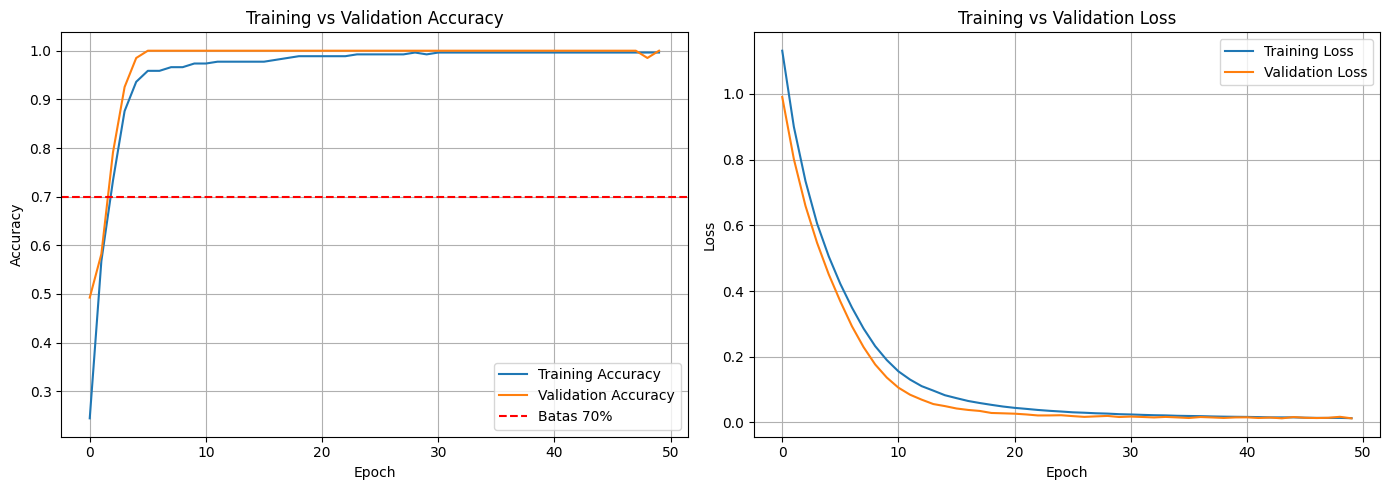

In [50]:
print("\n---  Menampilkan Grafik ---")

plt.figure(figsize=(14, 5))

# Plot Akurasi
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training vs Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.axhline(y=0.7, color='r', linestyle='--', label='Batas 70%') # Garis batas 70%
plt.legend()
plt.grid(True)

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

Sel ini memvisualisasikan data dari *history* pelatihan menggunakan `matplotlib`. Hasilnya adalah **dua plot grafik**:
1.  **Grafik Akurasi:** Menampilkan `Training Accuracy` vs `Validation Accuracy` yang keduanya naik stabil.
2.  **Grafik Loss:** Menampilkan `Training Loss` vs `Validation Loss` yang keduanya turun stabil.